In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [164]:
dx = 0.01
xs = np.arange(0, 1.1, dx)
dcrit = 2*dx
lp = 1.5*dcrit
thetacrit = np.arccos(np.radians(lp/dcrit))
thetacrit


1.5446133965177113

In [165]:
# n = len(xs)
# grid = np.zeros((n,n))
# c0 = 1
# for i, x in enumerate(xs):
#     grid[:, i] = c0 * x

# X, Y = np.meshgrid(xs, xs)


# plt.figure(figsize=(6, 5))

# plt.contourf(X, Y, grid, levels=10)
# plt.scatter(X,Y,s=1, color = "black")

# plt.colorbar(label="Chemical Concentration")
# plt.xlabel("x")
# plt.xlim((-.1,1.1))
# plt.ylim((-.1,1.1))
# plt.ylabel("y")
# #plt.title("Contour and Contourf of Grid")

# plt.tight_layout()
# plt.show()

In [166]:
### Now at point (0,0) we have 5 protrusions in random direction from 0 to pi 
### of fixed length 

In [167]:
thetarand = np.sort(np.random.uniform(0, np.pi,5)) 
### we always choose the smallest theta
theta = thetarand[0]
xinit = 0
yinit = 0
if theta < thetacrit:
    deltax = lp*np.cos(theta)
    deltay = lp*np.sin(theta)
    xnew = xinit + deltax
    ynew = yinit + deltay
xgrid = dx * np.round(xnew / dx)
ygrid = dx * np.round(ynew / dx)

In [168]:
def chemotaxis_walk(x0, y0, n_steps, dx, lp, thetacrit, L=1.0, n_angles=5):

    x, y = x0, y0
    path = [(x, y)]


    while not np.isclose(x, L):

        # sample angles and choose smallest
        thetarand = np.sort(np.random.uniform(0, np.pi, n_angles))
        theta = thetarand[0]

        # proposed move
        if theta < thetacrit:
            x_new = x + lp * np.cos(theta)
            y_new = y + lp * np.sin(theta)
        else:
            theta = float(np.sort(np.random.uniform(0, np.pi, 1)))
            x_new = x + lp * np.cos(theta)
            y_new = y + lp * np.sin(theta)

        # snap to nearest grid point
        x_grid = dx * np.round(x_new / dx)
        y_grid = dx * np.round(y_new / dx)

        # keep inside domain
        x_grid = np.clip(x_grid, 0, L)
        y_grid = np.clip(y_grid, 0, L)

        x, y = x_grid, y_grid
        path.append((x, y))

    return np.array(path)


In [175]:
path = chemotaxis_walk(x0=0.2,y0=0.5,n_steps=200,dx=dx,lp=lp,thetacrit=thetacrit)

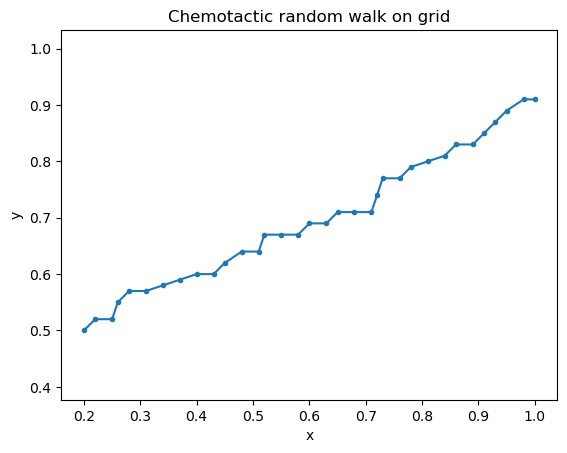

In [176]:
plt.plot(path[:,0], path[:,1], '-o', markersize=3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Chemotactic random walk on grid")
plt.axis("equal")
plt.show()